# Ecommerce Customer Churn Analysis and Prediction

## 1. Import Libraries

In [1]:
import numpy as np  # Imports the NumPy library for numerical operations and array handling.
import pandas as pd  # Imports the pandas library for data manipulation and analysis.
import matplotlib.pyplot as plt  # Imports Matplotlib's pyplot for creating static visualizations.
import seaborn as sns  # Imports Seaborn for statistical data visualization, built on top of Matplotlib.
import plotly.express as px  # Imports Plotly Express for easy-to-use interactive visualizations.
from sklearn.pipeline import Pipeline  # Imports Pipeline for creating machine learning workflows.
from sklearn.linear_model import LogisticRegression  # Imports LogisticRegression for classification tasks.
from sklearn.ensemble import RandomForestClassifier  # Imports RandomForestClassifier for ensemble-based classification.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay  # Imports metrics for evaluating model performance.
from sklearn.model_selection import train_test_split  # Imports function to split data into training and testing sets.
from sklearn.experimental import enable_iterative_imputer  # Enables the experimental IterativeImputer in scikit-learn.
from sklearn.impute import IterativeImputer, SimpleImputer  # Imports imputers to handle missing data.
from sklearn.preprocessing import StandardScaler, OneHotEncoder  # Imports tools for data preprocessing (scaling and encoding).
from sklearn.compose import ColumnTransformer  # Imports ColumnTransformer for applying different preprocessing steps to different columns.
from sklearn.model_selection import GridSearchCV  # Imports GridSearchCV for hyperparameter tuning.
from xgboost import XGBClassifier  # Imports XGBClassifier for gradient boosting-based classification.

import warnings
warnings.filterwarnings('ignore')  # Suppresses warnings to keep the output clean.

## 2. Overview Dataset

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numerical_cols]
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [6]:
# cek Missing values, duplicates, unique counts
missing = df.isnull().sum()
summary = pd.DataFrame({
    "dtypes": df.dtypes.astype(str),
    "missing_values": missing,
    "missing_pct": (missing / len(df) * 100).round(2),
    "unique_values": df.nunique()
})
print("Duplicate rows (all columns identical):", df.duplicated().sum())
print("Duplicate customerID values:", df['customerID'].duplicated().sum())
summary

Duplicate rows (all columns identical): 0
Duplicate customerID values: 0


,dtypes,missing_values,missing_pct,unique_values
customerID,object,0,0.0,7043
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,object,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,object,0,0.0,2
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


       Count  Percentage
Churn                   
No      5174       73.46
Yes     1869       26.54


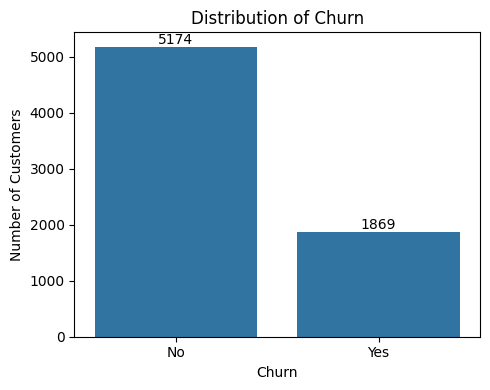

In [8]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

#visualisasi distribusi churn
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='Churn', order=['No', 'Yes'], ax=ax)
ax.set_title('Distribution of Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
for  p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 3. Data Quality Audit

What are we doing? A serious audit: hidden missing values, whitespace, inconsistent categories, impossible values, and wrong data types.

Why? df.isnull().sum() reported zero missing values everywhere, but that only catches actual NaNs. TotalCharges is stored as text, which is suspicious for a currency amount - blank strings " " are not NaN, so isnull() misses them entirely.

What should we learn? Whether the data is genuinely clean, and - for anything that isn't - what caused the problem before deciding how to fix it.

In [9]:
# Attempt a safe numeric conversion and see what breaks
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Row that fail numeric conversesion: {total_charges_numeric.isnull().sum()}")

problem_rows = df.loc[total_charges_numeric.isnull(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
problem_rows

Row that fail numeric conversesion: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [10]:
# What do these problem rows have in common?
print("Unique tenure values among problem rows:", problem_rows['tenure'].unique())
print("Raw TotalCharges value(s):", repr(df.loc[total_charges_numeric.isnull(), 'TotalCharges'].unique()))
print("Churn outcomes among problem rows:", problem_rows['Churn'].value_counts().to_dict())

Unique tenure values among problem rows: [0]
Raw TotalCharges value(s): array([' '], dtype=object)
Churn outcomes among problem rows: {'No': 11}


Cleaning decision - TotalCharges:

- What problem was found? 11 rows (0.16% of the data) contain a whitespace string " " instead of a number, silently blocking any direct numeric conversion.
- Why does it matter? As text, the column can't be used in any model, correlation, or plot. But naively dropping the rows would discard 11 real customers for no good reason.
- What is the actual cause? Every one of these 11 rows has tenure == 0 - brand-new customers who have not completed a billing cycle, so they genuinely have not accumulated a cumulative charge yet. This is not random corruption; it is a logical consequence of TotalCharges being a running total.
- What solution was applied? Convert with pd.to_numeric(errors='coerce'), then fill these 11 NaNs with 0, since a customer with 0 months of tenure has by definition been billed $0 cumulatively. We do not drop them - they are valid, very new customers (and notably, none of them churned).

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print("missing values after conversion:", df['TotalCharges'].isnull().sum())
print("dtype:" , df['TotalCharges'].dtype)


missing values after conversion: 0
dtype: float64


In [12]:
# Further checks: whitespace, inconsistent labels, impossible values
obj_cols = [c for c in df.columns if df[c].dtype == object and c != 'customerID']

ws = {c: int((df[c].astype(str) != df[c].astype(str).str.strip()).sum()) for c in obj_cols}
print("Columns with leading/trailing whitespace:", {k: v for k, v in ws.items() if v > 0} or "None found")

print("\nCategory labels per column (checking for typos / inconsistent casing):")
for c in obj_cols:
    print(f"  {c}: {sorted(df[c].unique())}")

print("\nImpossible-value checks:")
print("  Negative tenure:", (df['tenure'] < 0).sum())
print("  Negative MonthlyCharges:", (df['MonthlyCharges'] < 0).sum())
print("  Negative TotalCharges:", (df['TotalCharges'] < 0).sum())
print("  Max tenure (months):", df['tenure'].max())
print("  TotalCharges < MonthlyCharges while tenure > 1:",
      int(((df['TotalCharges'] < df['MonthlyCharges']) & (df['tenure'] > 1)).sum()))

Columns with leading/trailing whitespace: None found

Category labels per column (checking for typos / inconsistent casing):
  gender: ['Female', 'Male']
  Partner: ['No', 'Yes']
  Dependents: ['No', 'Yes']
  PhoneService: ['No', 'Yes']
  MultipleLines: ['No', 'No phone service', 'Yes']
  InternetService: ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: ['No', 'No internet service', 'Yes']
  OnlineBackup: ['No', 'No internet service', 'Yes']
  DeviceProtection: ['No', 'No internet service', 'Yes']
  TechSupport: ['No', 'No internet service', 'Yes']
  StreamingTV: ['No', 'No internet service', 'Yes']
  StreamingMovies: ['No', 'No internet service', 'Yes']
  Contract: ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling: ['No', 'Yes']
  PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
  Churn: ['No', 'Yes']

Impossible-value checks:
  Negative tenure: 0
  Negative MonthlyCharges: 0
  Negative TotalCharges: 0
  Max tenure (

Result of the audit: no whitespace issues, no inconsistent category spellings, no negative or impossible values, and tenure caps at a plausible 72 months. SeniorCitizen is stored as 0/1 rather than Yes/No like the other binary columns - not an error, just an inconsistent encoding convention worth remembering during EDA (it plots best as a category, not a continuous number). Aside from the TotalCharges fix, the dataset is clean.

## 4. Expaltory Data Analysis

### 4.1 Univariate Analysis

What are we doing? Examining the shape of the key numeric variables on their own, before looking at any relationship with churn.

Why? Distribution shape drives later choices: whether to scale features, whether "average" is even a meaningful summary, and whether sensible bins exist for grouping.

What should we learn? Whether these variables are well-behaved (roughly normal) or skewed/multi-modal in ways that hint at distinct customer sub-populations.

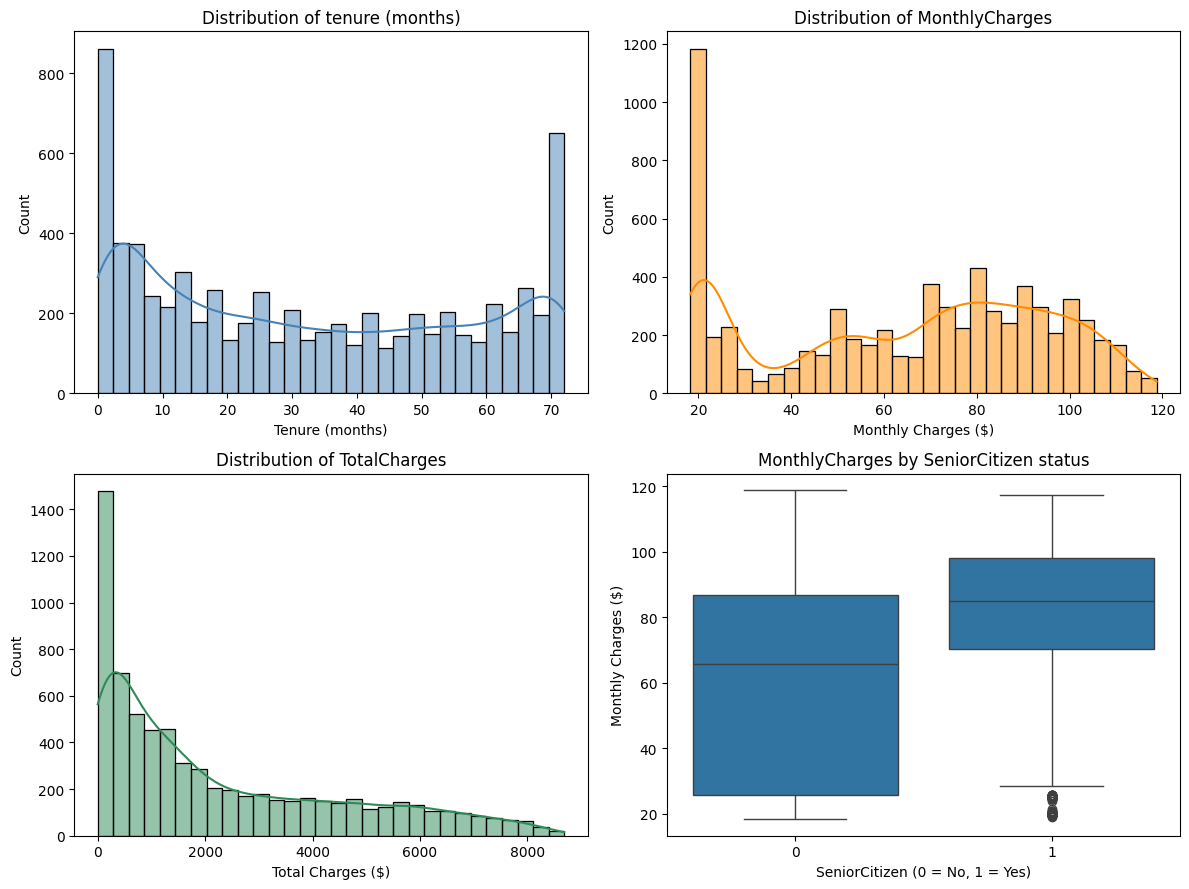

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80


In [13]:
fig, axes =plt.subplots(2, 2, figsize=(12,9))

sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title("Distribution of tenure (months)")
axes[0, 0].set_xlabel("Tenure (months)")

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title("Distribution of MonthlyCharges")
axes[0, 1].set_xlabel("Monthly Charges ($)")

sns.histplot(df['TotalCharges'], bins=30, kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title("Distribution of TotalCharges")
axes[1, 0].set_xlabel("Total Charges ($)")

sns.boxplot(data=df, y='MonthlyCharges', x='SeniorCitizen', ax=axes[1, 1])
axes[1, 1].set_title("MonthlyCharges by SeniorCitizen status")
axes[1, 1].set_xlabel("SeniorCitizen (0 = No, 1 = Yes)")
axes[1, 1].set_ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()

print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))

### 4.2 Categorical Variables vs. Churn

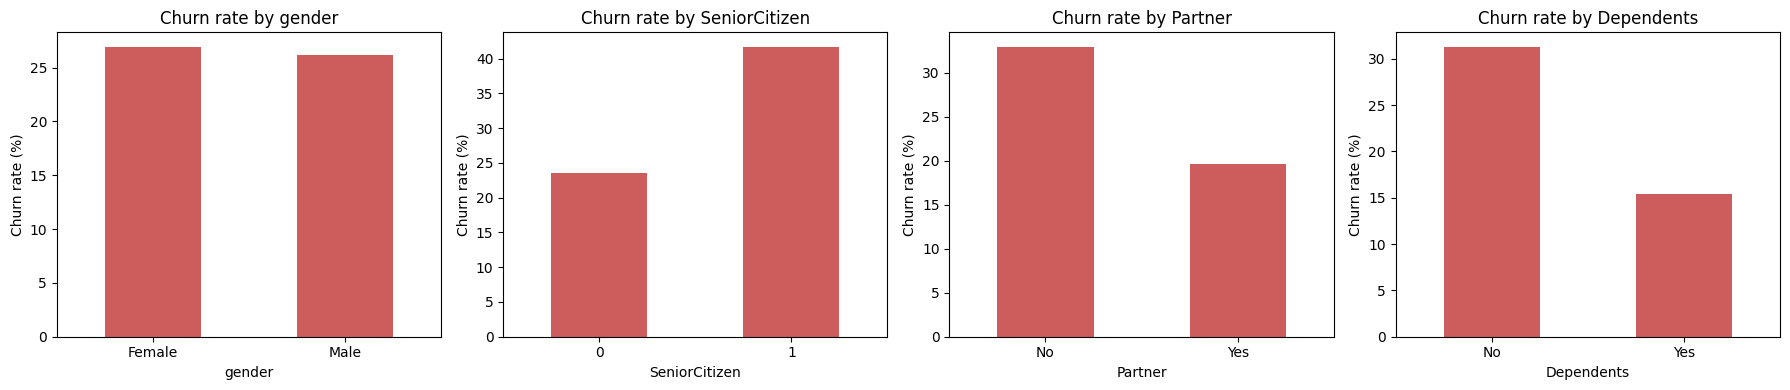

In [14]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, demo_cols):
    rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    rate.plot(kind='bar', ax=ax, color='indianred')
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

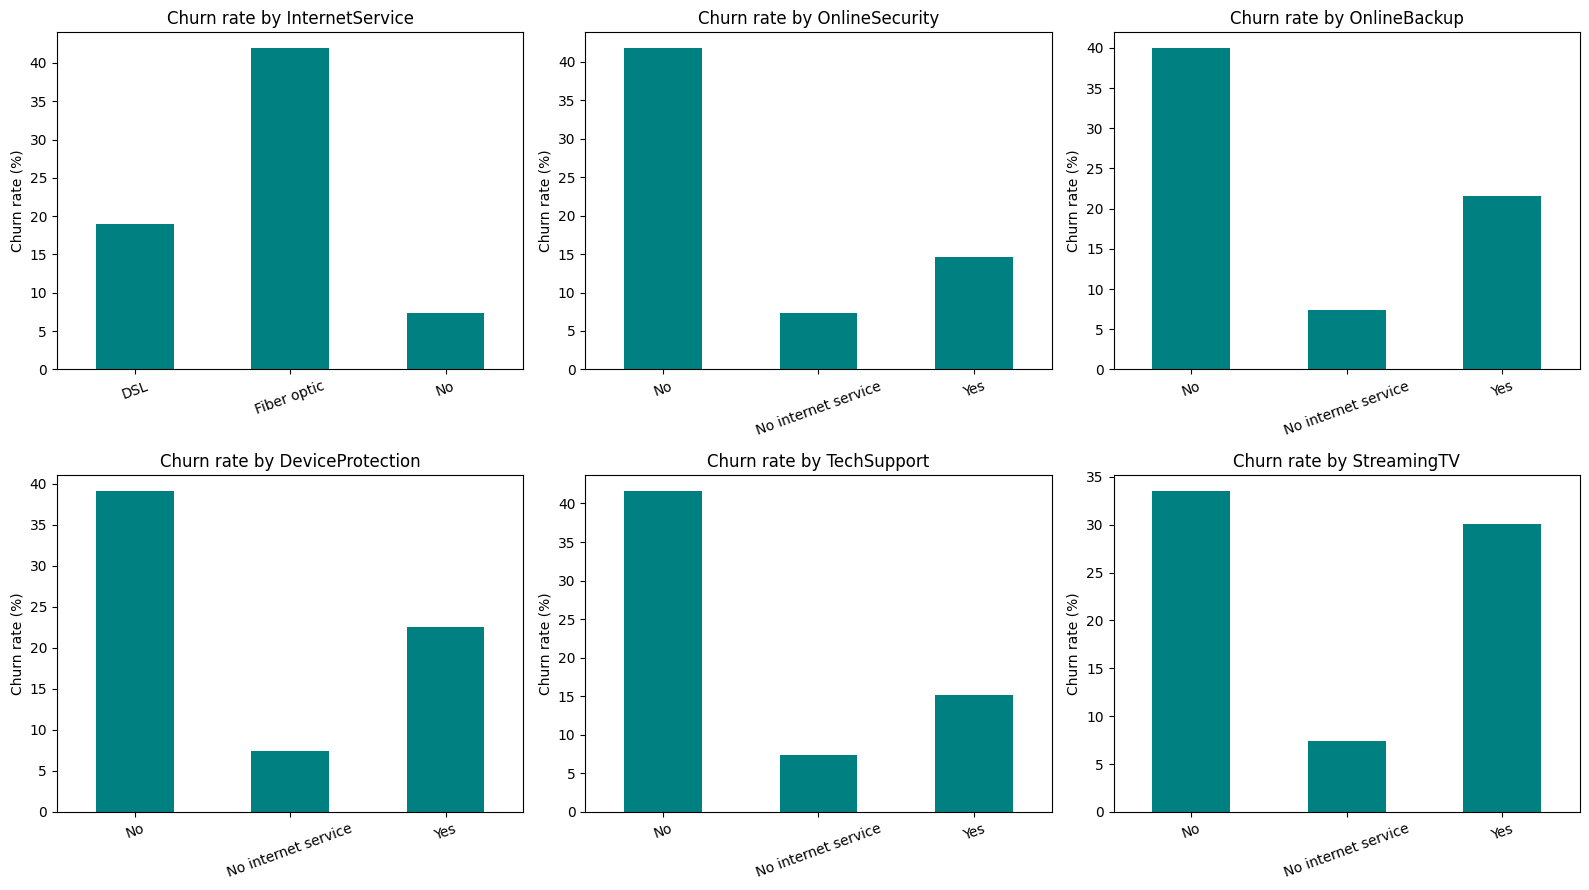

In [15]:
service_cols_plot = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), service_cols_plot):
    rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    rate.plot(kind='bar', ax=ax, color='teal')
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

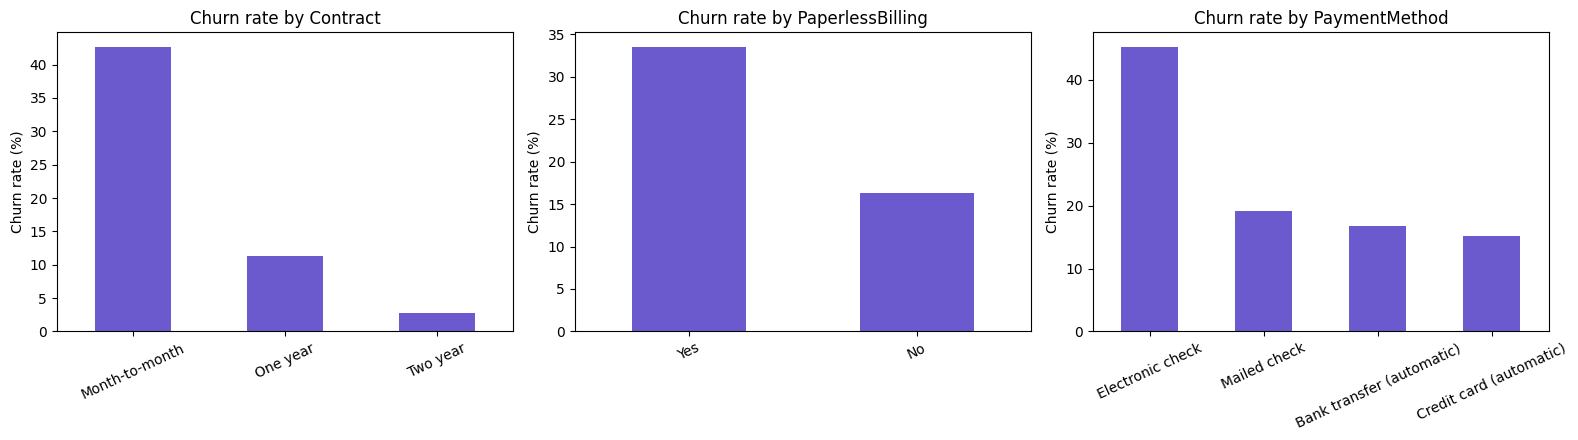

In [16]:
billing_cols_plot = ['Contract', 'PaperlessBilling', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, billing_cols_plot):
    rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    rate.sort_values(ascending=False).plot(kind='bar', ax=ax, color='slateblue')
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

What stands out already:

- gender produces almost identical churn rates for Male vs. Female - visually flat, confirmed statistically in Section 6.
- SeniorCitizen, Partner, and Dependents all show a visible gap: seniors, customers without a partner, and customers without dependents churn more.
- Customers without OnlineSecurity or TechSupport churn substantially more than those with it, and Fiber optic customers churn far more than DSL or no-internet customers.
- Contract and PaymentMethod show the largest visual gaps so far - month-to-month contracts and electronic-check payments stand out sharply. We quantify these precisely next.

## 5. Customer Churn Patterns - Count vs. Rate

What are we doing? Reporting, for each segment, both the number of customers and the churn rate within it.

Why? A segment can look important simply because it is large. Raw counts answer "where are most of my churners?"; churn rate answers "where is churn most likely?" These are different questions with different answers, and conflating them is a classic analytical error.

$$
\text{Churn Rate} =
\frac{\text{Churned Customers in Segment}}
{\text{Total Customers in Segment}}
\times 100\%
$$
 
What should we learn? Which segments are genuinely high-risk, as distinct from merely large.

In [17]:
def churn_rate_table(data, col):
    t = data.groupby(col)['Churn'].agg(
        customer_count='size',
        churn_rate=lambda s: (s == 'Yes').mean() * 100
    )
    return t.sort_values('churn_rate', ascending=False)

for col in ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'SeniorCitizen']:
    print(f"--- {col} ---")
    print(churn_rate_table(df, col).round(2))
    print()

--- Contract ---
                customer_count  churn_rate
Contract                                  
Month-to-month            3875       42.71
One year                  1473       11.27
Two year                  1695        2.83

--- InternetService ---
                 customer_count  churn_rate
InternetService                            
Fiber optic                3096       41.89
DSL                        2421       18.96
No                         1526        7.40

--- PaymentMethod ---
                           customer_count  churn_rate
PaymentMethod                                        
Electronic check                     2365       45.29
Mailed check                         1612       19.11
Bank transfer (automatic)            1544       16.71
Credit card (automatic)              1522       15.24

--- TechSupport ---
                     customer_count  churn_rate
TechSupport                                    
No                             3473       41.64
Yes        

### 5.1 Tenure Analysis
What are we doing? Grouping tenure into interpretable bands and measuring churn rate per band.

Why these bins? Rather than arbitrary or purely equal-width cuts, the bands are aligned to the contract lengths that actually exist in this dataset (1 and 2 years = 12 and 24 months), so each band maps to a real business milestone:

- 0-12 months: still inside a typical first-year window
- 13-24 months: through the one-year renewal point
- 25-48 months: established, multi-year customers
- 49+ months: the long-tenured, most loyal segment

These are a reasonable, explainable choice - not provably optimal. Section 8 tests how strongly the resulting grouping associates with churn, which is the check on whether the binning captured real signal.

              customer_count  churn_rate
tenure_group                            
0-12                    2186       47.44
13-24                   1024       28.71
25-48                   1594       20.39
49+                     2239        9.51


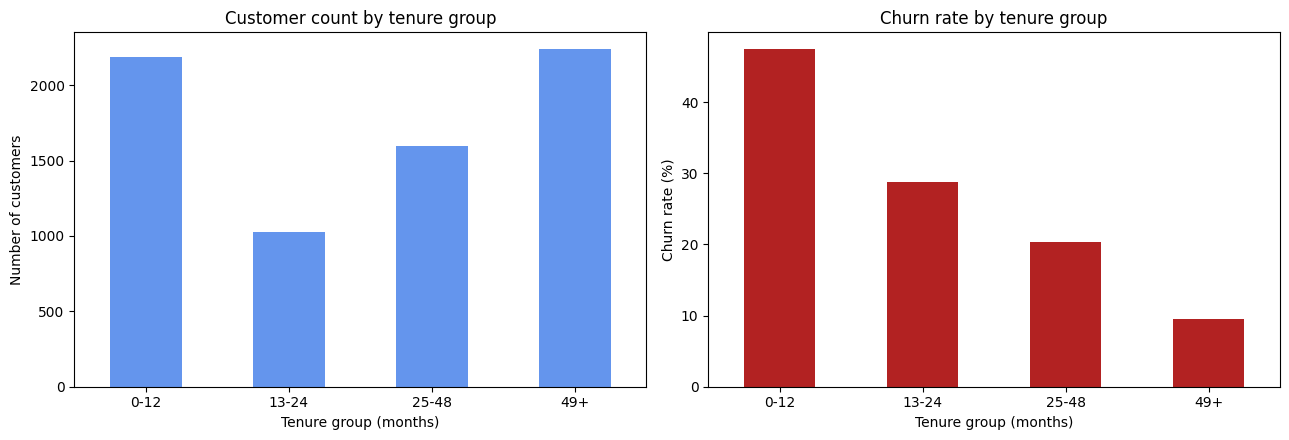

In [18]:
def tenure_group(t):
    if t <= 12:
        return '0-12'
    elif t <= 24:
        return '13-24'
    elif t <= 48:
        return '25-48'
    return '49+'

df['tenure_group'] = df['tenure'].apply(tenure_group)
order = ['0-12', '13-24', '25-48', '49+']

tenure_table = churn_rate_table(df, 'tenure_group').reindex(order)
print(tenure_table.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
tenure_table['customer_count'].plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title("Customer count by tenure group")
axes[0].set_ylabel("Number of customers")
axes[0].set_xlabel("Tenure group (months)")
axes[0].tick_params(axis='x', rotation=0)

tenure_table['churn_rate'].plot(kind='bar', ax=axes[1], color='firebrick')
axes[1].set_title("Churn rate by tenure group")
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_xlabel("Tenure group (months)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. Financial Analysis
- What are we doing? Examining MonthlyCharges, TotalCharges, and tenure in relation to churn.
- Why? Price is the variable business stakeholders reach for first, so it deserves careful treatment - including careful language.
- what should we learn? Whether spending is associated with churn, and why that association alone cannot support a pricing conclusion.

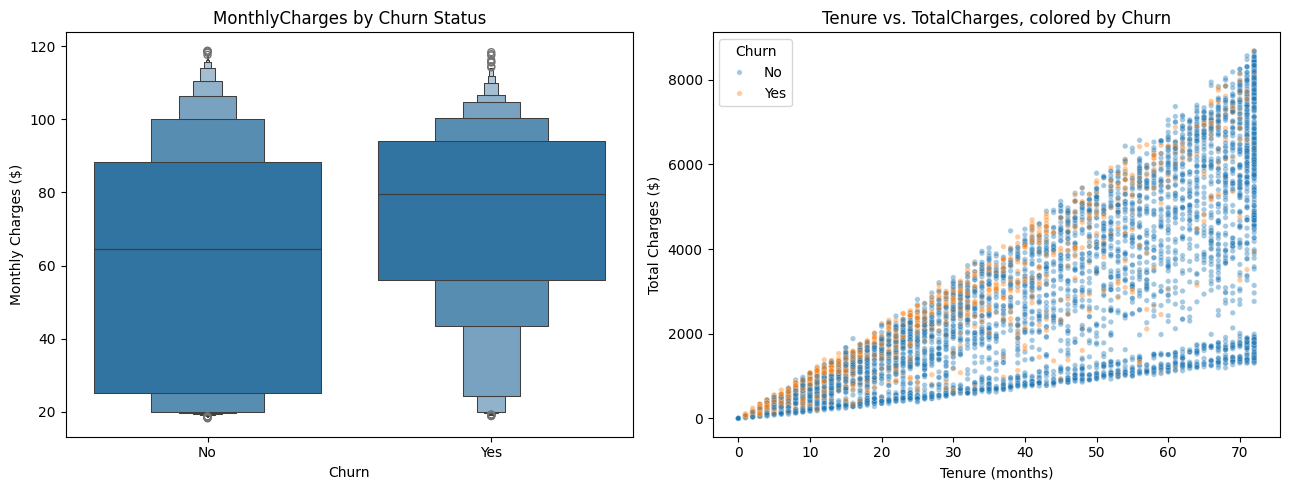

        mean    50%    std
Churn                     
No     61.27  64.43  31.09
Yes    74.44  79.65  24.67


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxenplot(data= df, x='Churn', y='MonthlyCharges', order= ['No', 'Yes'], ax=axes[0])
axes[0].set_title("MonthlyCharges by Churn Status")
axes[0].set_ylabel("Monthly Charges ($)")

sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.4, s = 15, ax=axes[1])
axes[1].set_title("Tenure vs. TotalCharges, colored by Churn")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Total Charges ($)")

plt.tight_layout()
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].describe()[['mean', '50%', 'std']].round(2))

Observations (association, not causation):

- Customers who churned have a higher median MonthlyCharges than customers who stayed. This aligns with the fiber-optic finding - fiber is the pricier internet tier and also the highest-churn one.
- The tenure-vs-TotalCharges scatter shows the two are naturally correlated (more months means more cumulative billing), and churned customers are visibly concentrated in the low-tenure, low-TotalCharges region.
- We deliberately avoid saying "higher prices cause churn." A defensible statement is: higher MonthlyCharges is associated with churn, largely because it correlates with fiber-optic internet and short tenure - both stronger, more specific signals. Testing a pricing hypothesis would require an experiment, not this dataset.

## 7. Multivariate Analysis
- What are we doing? Examining churn rate across combinations of variables.
- Why? Single-variable rates can mislead when the variables are themselves correlated. If fiber-optic customers are also disproportionately month-to-month, then attributing their churn to fiber alone double-counts the contract effect.
- What should we learn? Whether these effects are independent, compounding, or one merely standing in for another.

churn rate (%) by Contract and InternetService:
InternetService   DSL  Fiber optic    No
Contract                                
Month-to-month   32.2         54.6  18.9
One year          9.3         19.3   2.5
Two year          1.9          7.2   0.8


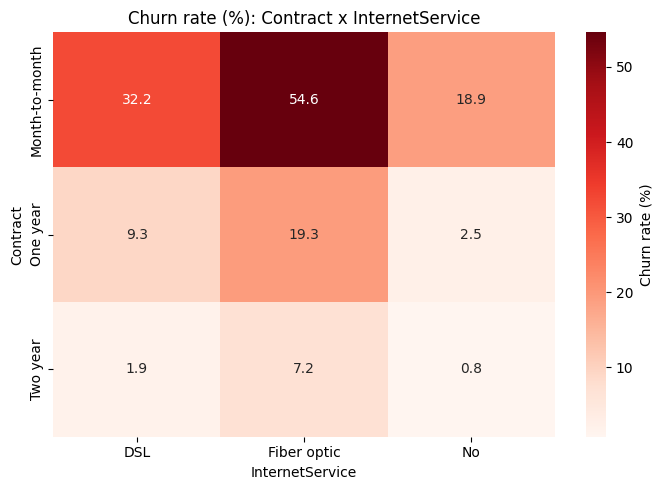

In [20]:
pivot1 = df.pivot_table(index='Contract', columns='InternetService', values='Churn', aggfunc=lambda s: (s == 'Yes').mean() * 100)
print("churn rate (%) by Contract and InternetService:")
print(pivot1.round(1))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot1, annot=True, fmt=".1f", cmap="Reds", ax=ax, cbar_kws={'label': 'Churn rate (%)'})
ax.set_title("Churn rate (%): Contract x InternetService")
plt.tight_layout()
plt.show()

churn rate (%) by Contract and PaymentMethod:
Contract                   Month-to-month  One year  Two year
PaymentMethod                                                
Bank transfer (automatic)            34.1       9.7       3.4
Credit card (automatic)              32.8      10.3       2.2
Electronic check                     53.7      18.4       7.7
Mailed check                         31.6       6.8       0.8


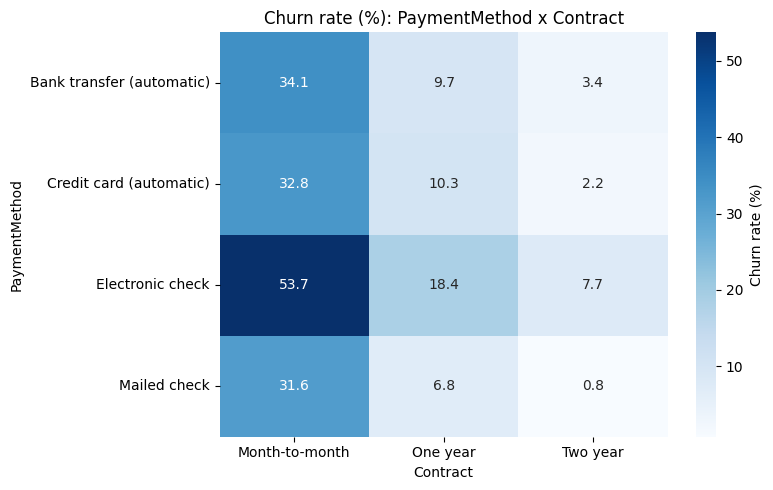

In [21]:
pivot2 = df.pivot_table(index='PaymentMethod', columns='Contract', values='Churn', aggfunc=lambda s: (s == 'Yes').mean() * 100)
print("churn rate (%) by Contract and PaymentMethod:")
print(pivot2.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot2, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={'label': 'Churn rate (%)'})
ax.set_title("Churn rate (%): PaymentMethod x Contract")
plt.tight_layout()
plt.show()

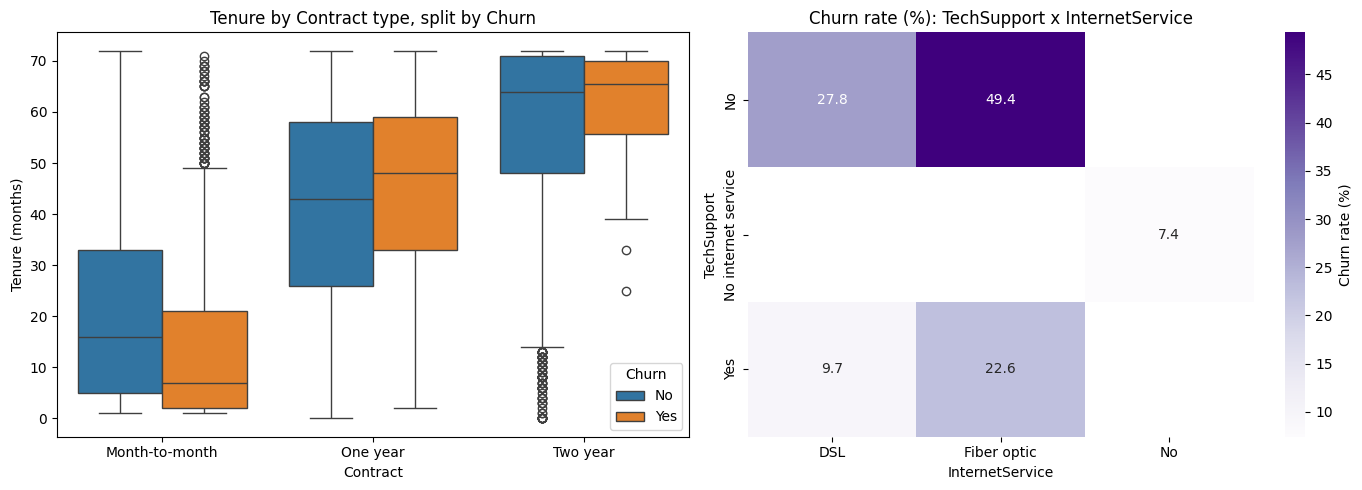

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Contract', y='tenure', hue='Churn', ax=axes[0])
axes[0].set_title("Tenure by Contract type, split by Churn")
axes[0].set_ylabel("Tenure (months)")

pivot3 = df.pivot_table(index='TechSupport', columns='InternetService', values='Churn',
                        aggfunc=lambda s: (s == 'Yes').mean() * 100)
sns.heatmap(pivot3, annot=True, fmt=".1f", cmap="Purples", ax=axes[1], cbar_kws={'label': 'Churn rate (%)'})
axes[1].set_title("Churn rate (%): TechSupport x InternetService")

plt.tight_layout()
plt.show()

Multivariate findings:

- The Contract x InternetService heatmap shows the two effects compound: month-to-month plus fiber-optic is the highest-churn combination in the grid, while two-year contracts with DSL or no internet are the safest. Neither variable alone tells the full story.
- PaymentMethod x Contract shows that within every contract type, electronic-check payers still churn more - so payment method carries some independent signal rather than acting purely as a proxy for contract type.
Within month-to-month contracts, churned customers skew toward much lower tenure than non-churned customers on the same contract - reinforcing that the danger zone is a new customer on a flexible contract.
- TechSupport x InternetService shows the support effect is concentrated among fiber-optic customers, where lacking tech support coincides with the highest churn rates of the grid.